Initial Record Counts:
Projects: 5939 rows, 36 columns
Roles: 25050 rows, 6 columns

Usable View Created: 25050 rows, 50 columns

--- DATA QUALITY CHECK SUMMARY ---
Duplicate Role Assignments: 3311
Civil Projects with Residential Units: 7
Status Claims Architect Appointed but Missing Role: 0

--- 4.1 CENTRAL TENDENCY ---
                            Mean      Median  Mean / Median Ratio
PROJECT_VALUE       2.878433e+07  1250000.00                23.03
SITE_AREA           2.169063e+03        0.23              9430.71
FLOOR_AREA          9.044998e+03      621.00                14.57
UNITS_RESIDENTIAL   3.732792e+01        4.00                 9.33
UNITS_INDUSTRIAL    5.321591e+00        1.00                 5.32
UNITS_SUBDIVISIONS  7.047368e+01       11.00                 6.41
AG_STOREYS          3.653044e+00        2.00                 1.83
BG_STOREYS          1.902439e+00        1.00                 1.90

--- 4.2 CORRELATIONS ---


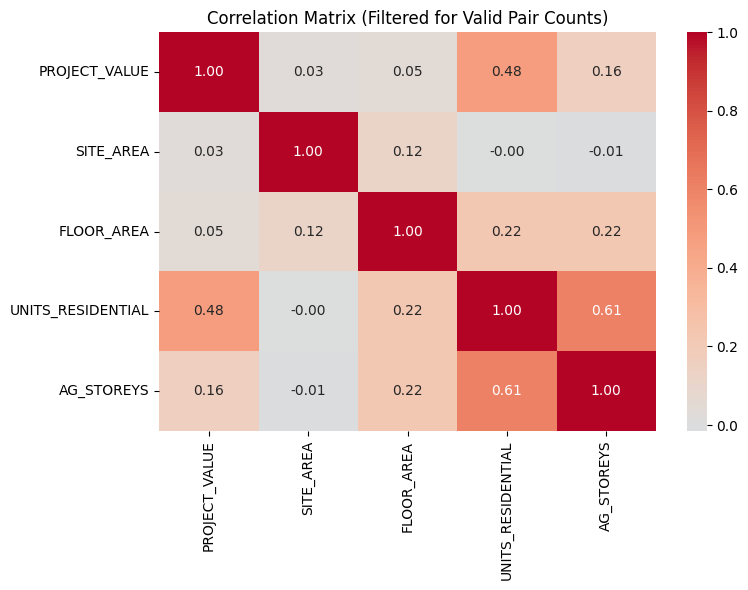


--- 4.3 DATA COMPLETENESS BY STATE ---
Completeness Rank (Avg Populated Fields per Project):
STATE
8      25.571429
100    25.251682
4      25.170732
3      24.681159
1      24.431000
2      24.269451
6      23.985915
5      23.808511
7      23.204545
Name: POPULATED_FIELDS, dtype: float64
State with highest completeness: State 8 (25.57 fields)

--- 4.4 CONTACT DISCLOSURE RATE BY STATE ---
       CONTACT_NAME  FIRM_PHONE  FIRM_E_MAIL  Overall_Disclosure
STATE                                                           
1              50.7        97.9         94.5                81.0
2              35.2        97.7         93.6                75.5
3              50.3        98.5         92.9                80.6
4              49.8        97.3         91.2                79.5
5              31.2        98.2         87.7                72.4
6              43.5        99.2         96.2                79.6
7              34.3        99.0         85.6                73.0
8              62.8  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PART 1: LOAD THE DATA & VERIFY SCHEMAS
# ==========================================

file_projects = "projects_data_with_errors.xlsx"
file_roles = "roles_data_with_errors.xlsx"
file_lookups = "lookup_tables.xlsx"

# Load primary datasets
projects = pd.read_excel(file_projects)
roles = pd.read_excel(file_roles)

# Load lookup tables into memory once
xls = pd.ExcelFile(file_lookups)
lookups = {sheet: xls.parse(sheet) for sheet in xls.sheet_names}

# Clean whitespace from lookup string columns (e.g. trailing tabs in status)
for sheet_name, df_lookup in lookups.items():
    for col in df_lookup.select_dtypes(include="object").columns:
        df_lookup[col] = df_lookup[col].astype(str).str.strip()

print("Initial Record Counts:")
print(f"Projects: {len(projects)} rows, {projects.shape[1]} columns")
print(f"Roles: {len(roles)} rows, {roles.shape[1]} columns")


# ==========================================
# PART 2: JOIN INTO ONE USABLE VIEW
# ==========================================

def build_usable_view(projects_df, roles_df, lookup_dict):
    """
    Builds a human-readable view by joining projects to roles,
    and resolving ID codes to text descriptions across lookup tables.
    """
    # Step 1: Join Roles to Projects
    # Expectation: Output length matches roles_df length (25,050 rows)
    combined = roles_df.merge(
        projects_df,
        on="PROJECTID",
        how="left",
        suffixes=("_ROLE", "_PROJECT"),
        indicator="_join_projects_roles"
    )

    # Step 2: Map Lookups
    # Map Country & State
    combined = combined.merge(
        lookup_dict['countries'], left_on="COUNTRYID", right_on="country_id", how="left"
    ).rename(columns={"reference": "COUNTRY_NAME"}).drop(columns=["country_id"], errors="ignore")

    combined = combined.merge(
        lookup_dict['states'], left_on="STATE", right_on="stateorprovince_id", how="left"
    ).rename(columns={"state": "STATE_NAME"}).drop(columns=["stateorprovince_id", "country_id"], errors="ignore")

    # Map Stage & Status
    combined = combined.merge(
        lookup_dict['stage'], left_on="STAGE_ID", right_on="projectstagesid", how="left"
    ).drop(columns=["projectstagesid"], errors="ignore")

    combined = combined.merge(
        lookup_dict['status'], left_on="STATUS_ID", right_on="project_statusid", how="left"
    ).drop(columns=["project_statusid"], errors="ignore")

    # Map Development Type & Contract Type
    combined = combined.merge(
        lookup_dict['development_type'], left_on="DEVID", right_on="devid", how="left"
    ).drop(columns=["devid"], errors="ignore")

    combined = combined.merge(
        lookup_dict['contract_type'], left_on="CONTRACT_TYPEID", right_on="contract_typeid", how="left"
    ).drop(columns=["contract_typeid"], errors="ignore")

    # Map Roles & Categories
    combined = combined.merge(
        lookup_dict['roles'], left_on="ROLEID", right_on="roleid", how="left"
    ).rename(columns={"roles": "ROLE_NAME"}).drop(columns=["roleid"], errors="ignore")

    combined = combined.merge(
        lookup_dict['categories'], left_on="MAIN_SUBCATEGORY_ID", right_on="category_id", how="left"
    ).rename(columns={"reference": "CATEGORY_NAME"}).drop(columns=["category_id"], errors="ignore")

    return combined

full_view = build_usable_view(projects, roles, lookups)
print(f"\nUsable View Created: {full_view.shape[0]} rows, {full_view.shape[1]} columns")


# ==========================================
# PART 3: REUSABLE DATA QUALITY CHECKS
# ==========================================

# 1. Referential Integrity Check
def check_referential_integrity(df, id_col, lookup_df, lookup_id_col):
    valid_ids = set(lookup_df[lookup_id_col].dropna())
    invalid_mask = df[id_col].notna() & (~df[id_col].isin(valid_ids))
    return df[invalid_mask]

# 2. Duplicate Assignments Check (Corrected Keys)
def check_duplicate_roles(roles_df):
    role_keys = ["PROJECTID", "ROLEID", "FIRM_NAME"]
    return roles_df[roles_df.duplicated(subset=role_keys, keep=False)]

# 3. Civil/Infrastructure + Residential Units Mismatch
def check_civil_residential_mismatch(projects_df):
    keywords = "road|bridge|rail|highway|infrastructure|civil"
    civil_mask = projects_df["PROJECT_TYPE"].astype(str).str.contains(keywords, case=False, na=False)
    units_mask = projects_df["UNITS_RESIDENTIAL"].fillna(0) > 0
    return projects_df[civil_mask & units_mask]

# 4. Status vs Role Mismatch
def check_status_role_mismatch(projects_df, roles_df, lookup_dict):
    roles_mapped = roles_df.merge(lookup_dict['roles'], left_on="ROLEID", right_on="roleid", how="left")
    architect_projects = set(roles_mapped[roles_mapped["roles"] == "Architect"]["PROJECTID"])

    # Identify projects where status text claims Architect is appointed
    arch_status_mask = projects_df["STATUS_TEXT"].astype(str).str.contains("Architect Appointed", case=False, na=False)
    missing_arch = projects_df[arch_status_mask & (~projects_df["PROJECTID"].isin(architect_projects))]
    return missing_arch

# 5. Outlier Detection (IQR Method)
def find_outliers_iqr(df, column):
    valid_series = df[column].dropna()
    q1 = valid_series.quantile(0.25)
    q3 = valid_series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df[(df[column] < lower) | (df[column] > upper)]

print("\n--- DATA QUALITY CHECK SUMMARY ---")
print("Duplicate Role Assignments:", len(check_duplicate_roles(roles)))
print("Civil Projects with Residential Units:", len(check_civil_residential_mismatch(projects)))
print("Status Claims Architect Appointed but Missing Role:", len(check_status_role_mismatch(projects, roles, lookups)))


# ==========================================
# PART 4: DATA ANALYSIS
# ==========================================

numeric_fields = [
    "PROJECT_VALUE", "SITE_AREA", "FLOOR_AREA",
    "UNITS_RESIDENTIAL", "UNITS_INDUSTRIAL", "UNITS_SUBDIVISIONS",
    "AG_STOREYS", "BG_STOREYS"
]

# 4.1 Central Tendency
print("\n--- 4.1 CENTRAL TENDENCY ---")
summary_stats = pd.DataFrame({
    "Mean": projects[numeric_fields].mean(),
    "Median": projects[numeric_fields].median()
})
summary_stats["Mean / Median Ratio"] = (summary_stats["Mean"] / summary_stats["Median"]).round(2)
print(summary_stats)

# 4.2 Correlations (Fixed pairwise sparsity issue)
print("\n--- 4.2 CORRELATIONS ---")
# Filter out fields with >90% missing values to prevent statistical artifacts
dense_numeric = [col for col in numeric_fields if projects[col].notna().sum() > 1000]
corr_matrix = projects[dense_numeric].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Filtered for Valid Pair Counts)")
plt.tight_layout()
plt.show()

# 4.3 Data Completeness by State
print("\n--- 4.3 DATA COMPLETENESS BY STATE ---")
projects["POPULATED_FIELDS"] = projects.notna().sum(axis=1)
completeness = projects.groupby("STATE")["POPULATED_FIELDS"].mean().sort_values(ascending=False)
print("Completeness Rank (Avg Populated Fields per Project):")
print(completeness)
print(f"State with highest completeness: State {completeness.idxmax()} ({completeness.max():.2f} fields)")

# 4.4 Contact Disclosure Rate by State
print("\n--- 4.4 CONTACT DISCLOSURE RATE BY STATE ---")
role_state = roles.merge(projects[["PROJECTID", "STATE"]], on="PROJECTID", how="left")
disclosure_cols = ["CONTACT_NAME", "FIRM_PHONE", "FIRM_E_MAIL"]

for col in disclosure_cols:
    role_state[col] = role_state[col].astype(str).str.lower().eq("available")

disclosure = role_state.groupby("STATE")[disclosure_cols].mean() * 100
disclosure["Overall_Disclosure"] = disclosure.mean(axis=1)
print(disclosure.round(1))
print(f"State with highest disclosure rate: State {disclosure['Overall_Disclosure'].idxmax()} ({disclosure['Overall_Disclosure'].max():.1f}%)")

# 4.5 Role Activity by Stage
print("\n--- 4.5 ROLE ACTIVITY BY STAGE ---")
target_roles = ["Architect", "Developer", "Builder / Main Contractor"]
stage_activity = full_view[full_view["ROLE_NAME"].isin(target_roles)]

cross_tab = pd.crosstab(
    stage_activity["ROLE_NAME"],
    stage_activity["project_stage"],
    normalize="index"
).round(4) * 100

print("Percentage Distribution of Roles Across Project Stages:")
print(cross_tab)

# 4.6 Top Roles for Category (Fixed ID mapping to 3023: Residential Estate / Townhouse)
print("\n--- 4.6 TOP ROLES FOR CATEGORY ---")
# Find Category ID matching Residential Estate/Townhouse/Apartments
cat_lookup = lookups['categories']
target_cat_ids = cat_lookup[cat_lookup['reference'].str.contains("Residential|Apartment|Townhouse", case=False, na=False)]['category_id'].tolist()

category_projects = projects[projects["MAIN_SUBCATEGORY_ID"].isin(target_cat_ids)]
category_roles = roles[roles["PROJECTID"].isin(category_projects["PROJECTID"])]

top_roles = category_roles.merge(
    lookups['roles'], left_on="ROLEID", right_on="roleid", how="left"
)["roles"].value_counts().head(5)

print(f"Top 5 roles for target residential categories (IDs {target_cat_ids}):")
print(top_roles)